<a href="https://colab.research.google.com/github/Maniacravi/pytorch-deep-learning/blob/main/03_pytorch_computer_vision_mani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision

## What we're going to cover

We're going to apply the PyTorch Workflow we've been learning in the past couple of sections to computer vision.

![a PyTorch workflow with a computer vision focus](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-pytorch-computer-vision-workflow.png)

Specifically, we're going to cover:

| **Topic** | **Contents** |
| ----- | ----- |
| **0. Computer vision libraries in PyTorch** | PyTorch has a bunch of built-in helpful computer vision libraries, let's check them out.  |
| **1. Load data** | To practice computer vision, we'll start with some images of different pieces of clothing from [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). |
| **2. Prepare data** | We've got some images, let's load them in with a [PyTorch `DataLoader`](https://pytorch.org/docs/stable/data.html) so we can use them with our training loop. |
| **3. Model 0: Building a baseline model** | Here we'll create a multi-class classification model to learn patterns in the data, we'll also choose a **loss function**, **optimizer** and build a **training loop**. |
| **4. Making predictions and evaluating model 0** | Let's make some predictions with our baseline model and evaluate them. |
| **5. Setup device agnostic code for future models** | It's best practice to write device-agnostic code, so let's set it up. |
| **6. Model 1: Adding non-linearity** | Experimenting is a large part of machine learning, let's try and improve upon our baseline model by adding non-linear layers. |
| **7. Model 2: Convolutional Neural Network (CNN)** | Time to get computer vision specific and introduce the powerful convolutional neural network architecture. |
| **8. Comparing our models** | We've built three different models, let's compare them. |
| **9. Evaluating our best model** | Let's make some predictions on random images and evaluate our best model. |
| **10. Making a confusion matrix** | A confusion matrix is a great way to evaluate a classification model, let's see how we can make one. |
| **11. Saving and loading the best performing model** | Since we might want to use our model for later, let's save it and make sure it loads back in correctly. |

## 0. Computer vision libraries in PyTorch

Before we get started writing code, let's talk about some PyTorch computer vision libraries you should be aware of.

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iterable over a dataset (created with `torch.utils.data.Dataset`). |

> **Note:** The `torch.utils.data.Dataset` and `torch.utils.data.DataLoader` classes aren't only for computer vision in PyTorch, they are capable of dealing with many different types of data.

Now we've covered some of the most important PyTorch computer vision libraries, let's import the relevant dependencies.


In [1]:
# Import pytorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


## 1. Getting a dataset


![example image of FashionMNIST](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-fashion-mnist-slide.png)
*`torchvision.datasets` contains a lot of example datasets you can use to practice writing computer vision code on. FashionMNIST is one of those datasets. And since it has 10 different image classes (different types of clothing), it's a multi-class classification problem.*

Later, we'll be building a computer vision neural network to identify the different styles of clothing in these images.

PyTorch has a bunch of common computer vision datasets stored in `torchvision.datasets`.

Including FashionMNIST in [`torchvision.datasets.FashionMNIST()`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html).

To download it, we provide the following parameters:
* `root: str` - which folder do you want to download the data to?
* `train: Bool` - do you want the training or test split?
* `download: Bool` - should the data be downloaded?
* `transform: torchvision.transforms` - what transformations would you like to do on the data?
* `target_transform` - you can transform the targets (labels) if you like too.

Many other datasets in `torchvision` have these parameter options.

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root = 'data', # Where data goes to
    train = True, # Get train data
    download = True,
    transform = ToTensor(), # Convert data to tensor
    target_transform = None # Transform labels or no?
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root = 'data', # Where data goes to
    train = False, # Get test data
    download = True,
    transform = ToTensor(), # Convert data to tensor
    target_transform = None # Transform labels or no?
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.44MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.86MB/s]


In [3]:
# Checkout first training sample
image, label = train_data[0]
print(f"Image shape: {image.shape}, Label: {label}")

Image shape: torch.Size([1, 28, 28]), Label: 9


The shape of the image tensor is `[1, 28, 28]` or more specifically:

```
[color_channels=1, height=28, width=28]
```

Having `color_channels=1` means the image is grayscale.

![example input and output shapes of the fashionMNIST problem](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-input-and-output-shapes.png)
*Various problems will have various input and output shapes. But the premise remains: encode data into numbers, build a model to find patterns in those numbers, convert those patterns into something meaningful.*

If `color_channels=3`, the image comes in pixel values for red, green and blue (this is also known as the [RGB color model](https://en.wikipedia.org/wiki/RGB_color_model)).

The order of our current tensor is often referred to as `CHW` (Color Channels, Height, Width).

There's debate on whether images should be represented as `CHW` (color channels first) or `HWC` (color channels last).

> **Note:** You'll also see `NCHW` and `NHWC` formats where `N` stands for *number of images*. For example if you have a `batch_size=32`, your tensor shape may be `[32, 1, 28, 28]`. We'll cover batch sizes later.

PyTorch generally accepts `NCHW` (channels first) as the default for many operators.

However, PyTorch also explains that `NHWC` (channels last) performs better and is [considered best practice](https://pytorch.org/blog/tensor-memory-format-matters/#pytorch-best-practice).

For now, since our dataset and models are relatively small, this won't make too much of a difference.

But keep it in mind for when you're working on larger image datasets and using convolutional neural networks (we'll see these later).

Let's check out more shapes of our data.

In [4]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [5]:
# see classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

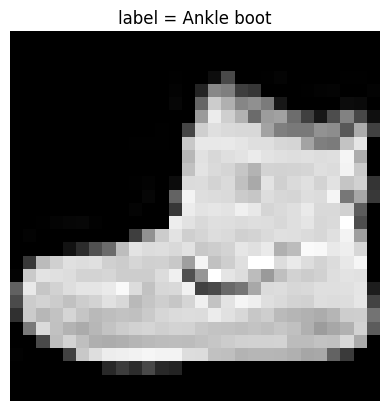

In [6]:
# Visualizing the data

image, label = train_data[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'label = {class_names[label]}')
plt.axis(False)
plt.show()

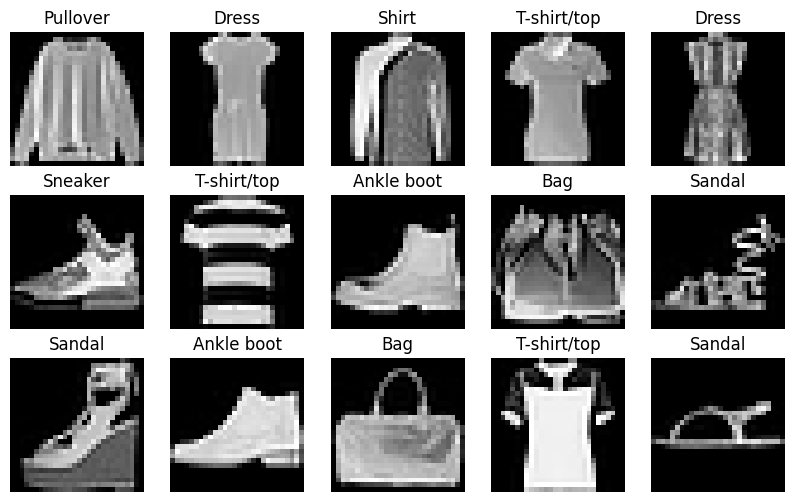

In [7]:
# Plot lots of these in subplots

fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(10, 6))

for row in axs:
  for ax in row:
    im_to_plot = int(torch.rand(1) * len(train_data.data)) # Picks a random number
    image, label = train_data[im_to_plot]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis(False)

plt.show()

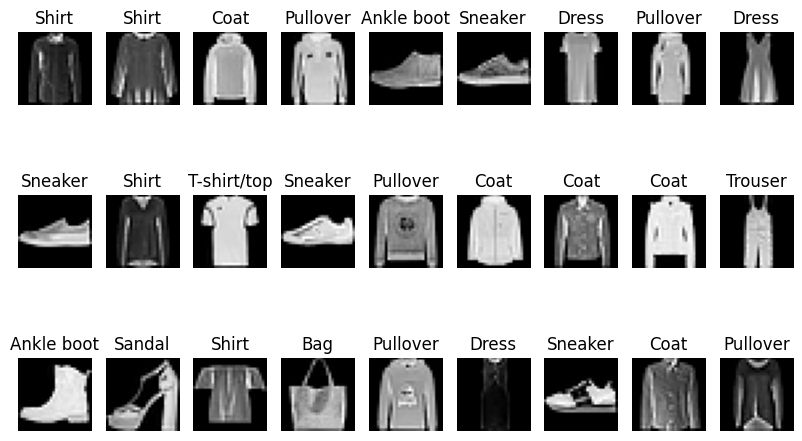

In [8]:
# Check something - see if we can flattenthe axs to just plot random plots

fig, axs = plt.subplots(nrows=3, ncols=9, figsize=(10, 6))

for ax in axs.flatten():
  im_to_plot = int(torch.rand(1) * len(train_data.data)) # Picks a random number
  image, label = train_data[im_to_plot]
  ax.imshow(image.squeeze(), cmap='gray')
  ax.set_title(class_names[label])
  ax.axis(False)

plt.show() # Works!!

## 2. Prepare DataLoader

Now we've got a dataset ready to go.

The next step is to prepare it with a [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) or `DataLoader` for short.

The `DataLoader` does what you think it might do.

It helps load data into a model.

For training and for inference.

It turns a large `Dataset` into a Python iterable of smaller chunks.

These smaller chunks are called **batches** or **mini-batches** and can be set by the `batch_size` parameter.

Why do this?

Because it's more computationally efficient.

In an ideal world you could do the forward pass and backward pass across all of your data at once.

But once you start using really large datasets, unless you've got infinite computing power, it's easier to break them up into batches.

It also gives your model more opportunities to improve.

With **mini-batches** (small portions of the data), gradient descent is performed more often per epoch (once per mini-batch rather than once per epoch).

What's a good batch size?

[32 is a good place to start](https://twitter.com/ylecun/status/989610208497360896?s=20&t=N96J_jotN--PYuJk2WcjMw) for a fair amount of problems.

But since this is a value you can set (a **hyperparameter**) you can try all different kinds of values, though generally powers of 2 are used most often (e.g. 32, 64, 128, 256, 512).

![an example of what a batched dataset looks like](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-batching-fashionmnist.png)
*Batching FashionMNIST with a batch size of 32 and shuffle turned on. A similar batching process will occur for other datasets but will differ depending on the batch size.*

Let's create `DataLoader`'s for our training and test sets.

In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False) # Don't necessarily have to shuffle the test dataset

# Let's check teh data out
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f'Len of train dataloader: {len(train_dataloader)} batches of 32 - totaling {len(train_dataloader) * 32} images')
print(f'Len of test dataloader: {len(test_dataloader)} batches of 32 - totaling {len(test_dataloader) * 32} images')

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d0cae547f90>, <torch.utils.data.dataloader.DataLoader object at 0x7d0cadf0c6d0>)
Len of train dataloader: 1875 batches of 32 - totaling 60000 images
Len of test dataloader: 313 batches of 32 - totaling 10016 images


In [10]:
# Checkout what's inside a dataloader

train_features_batch, train_labels_batch = next(iter(train_dataloader))
print(f'Feature batch shape: {train_features_batch.size()}')
print(f'Labels batch shape: {train_labels_batch.size()}')

Feature batch shape: torch.Size([32, 1, 28, 28])
Labels batch shape: torch.Size([32])


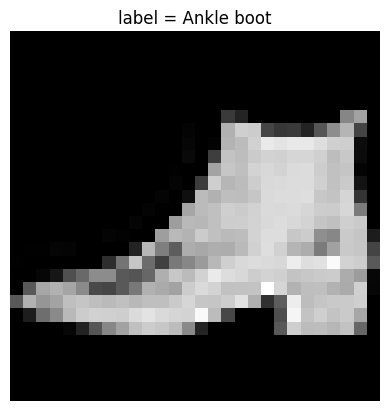

In [11]:
# Show a sample

# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_labels_batch), size=[1]).item()

img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'label = {class_names[label]}')
plt.axis(False)
plt.show()

## 3. Model 0: Baseline Model

Baseline model that will be improved upon in the future

In [12]:
# creating a flatten layer

flatten_model = nn.Flatten() # Any nn.Module can be used as a model on their own

x = train_features_batch[0]

output = flatten_model(x)
x.shape, output.shape


(torch.Size([1, 28, 28]), torch.Size([1, 784]))

Essentially, just converts the 28 x 28 matrix to a vector. NNs like their inputs as vectors!

In [13]:
# Now create the baseline model

from torch import nn

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

Now we've got the model. We need to instantiate it

In [14]:
# Instantiate the model

torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, hidden_units=10, output_shape=len(class_names)) # 28*28 = 784
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [16]:
# Check if the model is in cpu or gpu

next(model_0.parameters()).device

device(type='cpu')

### Setup loss, optimizer and accuracy metrics

In [17]:
# Loss and optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [19]:
# Let's import accuracy fn from torchmetrics

! pip install torchmetrics -q
import torchmetrics

accuracy_fn = torchmetrics.Accuracy(task='multiclass', num_classes=len(class_names))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.7 MB/s eta 0:00:00


We've got all the functions ready, now we can train the model. But let's create a function to time our code

In [20]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### Create a training and testing loop

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*.
4. Print out what's happening.
5. Time it all (for fun).

In [22]:
from tqdm.auto import tqdm # For progress bar

# Set the seed and start timer
torch.manual_seed(42)
train_time_cpu_start = timer()

# number of epochs
epochs = 3 # We'll keep this small for now

for epoch in tqdm(range(epochs)): # wrap the iterator through tqdm
  print(f"Epoch: {epoch}\n-------")
  # Training
  train_loss = 0
  train_acc = 0

  # Loop through training batches
  for batch, (X, y) in enumerate(train_dataloader):
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calcualte loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulatively add up the loss per epoch

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Train accuracy
    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += accuracy_fn(y_pred_class, y) * 100

    # printout what's happening
    if batch % 400 == 0:
      print(f'Processed {batch} of {len(train_dataloader)} batches')

  # Divide total train loss by length of train dataloader - get average
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  # Testing loop
  model_0.eval() # put the model in eval mode
  test_loss, test_acc = 0, 0
  with torch.inference_mode(): # turn on inference mode
    for X, y in test_dataloader:
      # Forward pass
      test_pred = model_0(X)

      # Calculate loss
      test_loss += loss_fn(test_pred, y)

      # Calculate accuracy
      test_pred_class = torch.argmax(torch.softmax(test_pred, dim=1), dim=1)
      test_acc += accuracy_fn(test_pred_class, y) * 100

    # Claculate average loss and accuracy per batch
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.5f} | Train acc: {train_acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

# Claculate training time
train_time_cpu_end = timer()
total_train_time_cpu = print_train_time(start=train_time_cpu_start, end=train_time_cpu_end, device=str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Processed 0 of 1875 batches
Processed 400 of 1875 batches
Processed 800 of 1875 batches
Processed 1200 of 1875 batches
Processed 1600 of 1875 batches

Train loss: 0.44395 | Train acc: 84.43% | Test loss: 0.46506 | Test acc: 83.65%
Epoch: 1
-------
Processed 0 of 1875 batches
Processed 400 of 1875 batches
Processed 800 of 1875 batches
Processed 1200 of 1875 batches
Processed 1600 of 1875 batches

Train loss: 0.43662 | Train acc: 84.82% | Test loss: 0.46453 | Test acc: 83.89%
Epoch: 2
-------
Processed 0 of 1875 batches
Processed 400 of 1875 batches
Processed 800 of 1875 batches
Processed 1200 of 1875 batches
Processed 1600 of 1875 batches

Train loss: 0.43045 | Train acc: 84.88% | Test loss: 0.46594 | Test acc: 83.93%
Train time on cpu: 30.118 seconds


The model did pretty good actually!

## 4. Make Predictions and get model_0 results

In [24]:
torch.manual_seed(42)

def eval_model(model: nn.Module, data_loader: DataLoader, loss_fn: nn.Module, accuracy_fn):
  """Returns a dictionary containing the results of model predicting on data_loader.

  Args:
    model (nn.Module): A PyTorch model capable of making predictions
    data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
  """

  loss, acc = 0, 0
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:

      # Forward pass
      y_pred = model(X)

      # Accumulate loss and accuracy
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(torch.softmax(y_pred, dim=1).argmax(dim=1), y) * 100

    # Average loss and accuracy
    loss = loss / len(data_loader)
    acc = acc / len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
          "model_acc": acc.item()}

# Calculate model_0 results
model_0_results = eval_model(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4659360349178314,
 'model_acc': 83.92572021484375}

## 5. Setup Device Agnostic code

In [25]:
# Setup device agnostic code

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Let's train the model on GPU to see how much faster they are

## Model 1: Better model with non-linearity

Add some non-linearity to the model - Add some ReLu layers

In [28]:
# Create a non-linear model
class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x):
    return self.layer_stack(x)


In [29]:
# instantiate model
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784, hidden_units=10, output_shape=len(class_names)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [32]:
# Check if model is in right device
next(model_1.parameters()).device

device(type='cuda', index=0)

In [33]:
# Define loss and optimizer and accuracy
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
accuracy_fn = torchmetrics.Accuracy(task='multiclass', num_classes=len(class_names)).to(device)

### Write functions for training and tetsing loops

In [34]:
def training_step(model: torch.nn.Module,
                  data_loader: torch.utils.data.DataLoader,
                  loss_fn: torch.nn.Module,
                  optimizer: torch.optim.Optimizer,
                  accuracy_fn,
                  device: torch.device = device):

  train_loss, train_acc = 0, 0
  model.to(device)
  model.train()

  for batch, (X, y) in enumerate(data_loader):
    # Send data to correct device
    X, y = X.to(device), y.to(device)

    # forward pass
    y_pred = model(X)

    # calculate loss and acc
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(torch.softmax(y_pred, dim=1).argmax(dim=1), y) * 100

    # zero grad
    optimizer.zero_grad()

    # loss backward
    loss.backward()

    # optimizer step
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f'Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%')

# Do the same for testing step
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):

  test_step_loss, test_step_acc = 0, 0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for X, y in data_loader:
      # Send data to correct device
      X, y = X.to(device), y.to(device)

      # forward pass
      test_pred = model(X)

      # calculate loss and acc
      test_step_loss += loss_fn(test_pred, y)
      test_step_acc += accuracy_fn(torch.softmax(test_pred, dim=1).argmax(dim=1), y) * 100

    test_step_loss /= len(data_loader)
    test_step_acc /= len(data_loader)

    print(f'Test loss: {test_step_loss:.5f} | Test acc: {test_step_acc:.2f}%')



### Train model on GPU and time it

In [35]:
torch.manual_seed(42)

train_time_start = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')

  training_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)
  test_step(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

train_time_end = timer()
train_time_model_1 = print_train_time(start=train_time_start, end=train_time_end, device=str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 1.09199 | Train acc: 61.34%
Test loss: 0.95636 | Test acc: 65.00%
Epoch: 1
-------
Train loss: 0.78101 | Train acc: 71.93%
Test loss: 0.72227 | Test acc: 73.91%
Epoch: 2
-------
Train loss: 0.67027 | Train acc: 75.94%
Test loss: 0.68500 | Test acc: 75.02%
Train time on cuda:0: 37.811 seconds


In [36]:
# Let's evaluate our model

torch.manual_seed(42)
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_1_results

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

This is because the eval function we have is not device agnostic. Let's make it so

In [38]:
# rewrite eval_model function to be device agnostic
torch.manual_seed(42)
def eval_model(model: nn.Module, data_loader: DataLoader, loss_fn: nn.Module, accuracy_fn, device: torch.device = device):
  """Returns a dictionary containing the results of model predicting on data_loader.

  Args:
    model (nn.Module): A PyTorch model capable of making predictions
    data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
    loss_fn (torch.nn.Module): The loss function of model.
    accuracy_fn: An accuracy function to compare the models predictions
    to the truth labels.
    device (torch.device, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
  """

  loss, acc = 0,0
  model.eval()
  model.to(device)
  with torch.inference_mode():
    for X, y in data_loader:
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # Forward pass
      y_pred = model(X)

      # Calculate loss and accuracy
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(torch.softmax(y_pred, dim=1).argmax(dim=1), y) * 100

    # Calculate average loss and accuracy per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc.item()}

# Calculate model_1 results with new function
model_1_results = eval_model(model=model_1, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996612548828}

In [39]:
# Check baseline results
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4659360349178314,
 'model_acc': 83.92572021484375}